# E-Commerce Funnel & Customer Analytics

**Business context:** This project simulates an end-to-end e-commerce analytics workflow — diagnosing where users drop off in the purchase funnel, which acquisition channels drive volume, and what retention patterns suggest about re-engagement strategy.

## Objectives:
1. Analyze user progression through the purchase funnel.
2. Identify which traffic sources drive the conversion rates.
3. Evaluate revenue drivers across departments, brands and customer segments.
4. Measure customer retention and repeat purchase behavior using cohort analysis.

### Dataset: 
Five interconnected tables - events, orders, order_items, users and products - covering user sessions, transactions and product metadata.

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
plt.rcParams['figure.figsize']=(10, 5)
plt.rcParams['axes.titlesize']=14
plt.rcParams['axes.labelsize']=12

In [2]:
# Loading events data
events=pd.read_csv('events.csv')
events.head()

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,traffic_source,uri,event_type
0,2198523,NaN,3,83889ed2-2adc-4b9a-af5d-154f6998e778,2021-06-17 17:30:00+00:00,138.143.9.202,São Paulo,São Paulo,02675-031,Chrome,Adwords,/cancel,cancel
1,1773216,NaN,3,7a3fc3f2-e84f-44fe-8876-eff76741f7a3,2020-08-07 08:41:00+00:00,85.114.141.79,Santa Isabel,São Paulo,07500-000,Safari,Adwords,/cancel,cancel
2,2380515,NaN,3,13d9b2fb-eee1-43fd-965c-267b38dd7125,2021-02-15 18:48:00+00:00,169.250.255.132,Mairiporã,São Paulo,07600-000,IE,Adwords,/cancel,cancel
3,2250597,NaN,3,96f1d44e-9621-463c-954c-d8deb7fffe7f,2022-03-30 10:56:00+00:00,137.25.222.160,Cajamar,São Paulo,07750-000,Chrome,Adwords,/cancel,cancel
4,1834446,NaN,3,d09dce10-a7cb-47d3-a9af-44975566fa03,2019-09-05 01:18:00+00:00,161.114.4.174,São Paulo,São Paulo,09581-680,Chrome,Email,/cancel,cancel


In [3]:
events.shape

(2431963, 13)

In [4]:
events.isnull().sum()

id                       0
user_id            1125671
sequence_number          0
session_id               0
created_at               0
ip_address               0
city                 23080
state                    0
postal_code              0
browser                  0
traffic_source           0
uri                      0
event_type               0
dtype: int64

In [5]:
events.event_type.value_counts()

event_type
product       845607
cart          595994
department    595323
purchase      181759
cancel        125568
home           87712
Name: count, dtype: int64

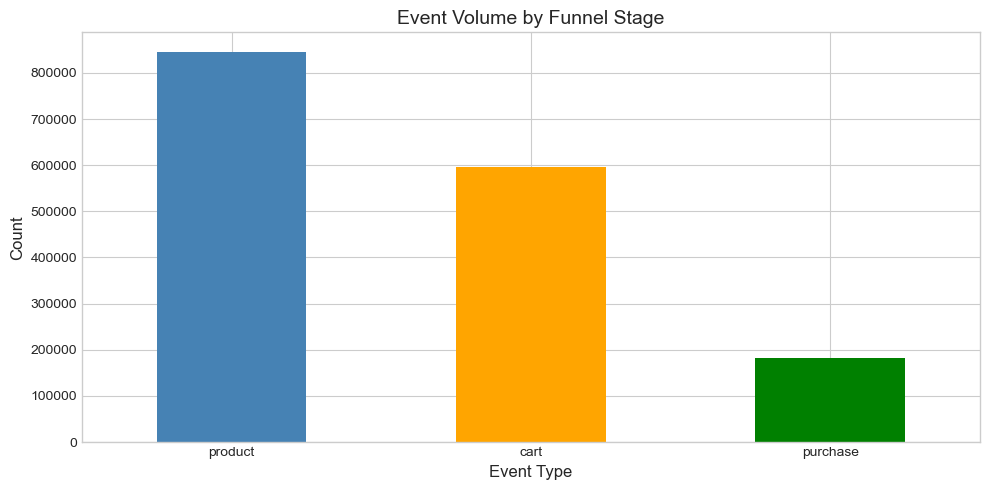

In [11]:
# Plotting Count by Event
funnel_events_counts=events[events['event_type'].isin(['product', 'cart', 'purchase'])]['event_type'].value_counts()
funnel_events_counts=funnel_events_counts.reindex(['product', 'cart', 'purchase'])
funnel_events_counts.plot(kind='bar', color=['steelblue', 'orange', 'green'])
plt.title('Event Volume by Funnel Stage')
plt.xlabel('Event Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

From the above graph, we infer that most customers are just looking at the product and adding it to cart rather than actually making a purchase.

In [12]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2431963 entries, 0 to 2431962
Data columns (total 13 columns):
 #   Column           Dtype              
---  ------           -----              
 0   id               int64              
 1   user_id          float64            
 2   sequence_number  int64              
 3   session_id       object             
 4   created_at       datetime64[ns, UTC]
 5   ip_address       object             
 6   city             object             
 7   state            object             
 8   postal_code      object             
 9   browser          object             
 10  traffic_source   object             
 11  uri              object             
 12  event_type       object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(2), object(9)
memory usage: 241.2+ MB


In [13]:
# Converting 'created_at' column to datetime datatype
events['created_at']=pd.to_datetime(events['created_at'], format='mixed')

In [14]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2431963 entries, 0 to 2431962
Data columns (total 13 columns):
 #   Column           Dtype              
---  ------           -----              
 0   id               int64              
 1   user_id          float64            
 2   sequence_number  int64              
 3   session_id       object             
 4   created_at       datetime64[ns, UTC]
 5   ip_address       object             
 6   city             object             
 7   state            object             
 8   postal_code      object             
 9   browser          object             
 10  traffic_source   object             
 11  uri              object             
 12  event_type       object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(2), object(9)
memory usage: 241.2+ MB


In [15]:
events.isnull().sum()

id                       0
user_id            1125671
sequence_number          0
session_id               0
created_at               0
ip_address               0
city                 23080
state                    0
postal_code              0
browser                  0
traffic_source           0
uri                      0
event_type               0
dtype: int64

There are many null values in user_id column. This implies that nearly half the users have not logged in, meaning they might just be scrolling through the products.

### Building Sequential Funnel

The funnel was constructed at session level using ordered event sequences. 
Each session's events were sorted by sequence_number to preserve chronological 
order. A session was counted at each stage only if the event occurred after 
the previous stage within the same session:

- **Viewed Product:** session contains a `product` event  
- **Added to Cart:** `cart` event occurred after product view  
- **Purchased:** `purchase` event occurred after cart addition

In [16]:
# Keeping only relevant funnel events
funnel_events=events[events['event_type'].isin(['product', 'cart', 'purchase'])].copy()

In [17]:
# Sort events within each session
funnel_events=funnel_events.sort_values(['session_id', 'sequence_number'])

In [18]:
funnel_data=[]

In [19]:
# Looping through each session
for session_id, session in funnel_events.groupby('session_id'):
    event_list=session['event_type'].to_list()

    # product view
    viewed_product='product' in event_list

    # cart after product
    added_cart=False

    if viewed_product:
        product_index=event_list.index('product')

        if 'cart' in event_list[product_index+1:]:
            added_cart=True

    # purchased after cart
    purchased=False

    if added_cart:
        cart_index=event_list.index('cart')

        if 'purchase' in event_list[cart_index+1:]:
            purchased=True

    # saving session results
    funnel_data.append({
        'session_id':session_id,
        'viewed_product':viewed_product,
        'added_cart':added_cart,
        'purchased':purchased
   })

In [20]:
# Converting to dataframe
ordered_funnel=pd.DataFrame(funnel_data)

In [21]:
ordered_funnel.iloc[:,1:]=(ordered_funnel.iloc[:,1:]).astype(int)

C:\Users\DELL\AppData\Local\Temp\ipykernel_19816\3110220493.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0         1
1         1
2         1
3         1
4         1
         ..
681754    1
681755    1
681756    1
681757    1
681758    1
Name: viewed_product, Length: 681759, dtype: int64' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ordered_funnel.iloc[:,1:]=(ordered_funnel.iloc[:,1:]).astype(int)
C:\Users\DELL\AppData\Local\Temp\ipykernel_19816\3110220493.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0         1
1         1
2         1
3         1
4         1
         ..
681754    1
681755    0
681756    0
681757    1
681758    1
Name: added_cart, Length: 681759, dtype: int64' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ordered_funnel.iloc[:,1:]=

In [22]:
# Funnel Conversion Rates
funnel_rates=ordered_funnel[['viewed_product', 'added_cart', 'purchased']].mean()
print(funnel_rates)

viewed_product    1.000000
added_cart        0.633869
purchased         0.266603
dtype: float64


In [23]:
# Conditional Funnel Conversions

# product to cart conversion
product_to_cart = (
    ordered_funnel['added_cart'].sum()
    /
    ordered_funnel['viewed_product'].sum()
)

print("\nProduct to Cart Conversion Rate:")
print(round(product_to_cart * 100, 2), "%")


Product to Cart Conversion Rate:
63.39 %


In [24]:
# cart to purchase conversion
cart_to_purchase = (
    ordered_funnel['purchased'].sum()
    /
    ordered_funnel['added_cart'].sum()
)

print("\nCart to Purchase Conversion Rate:")
print(round(cart_to_purchase * 100, 2), "%")


Cart to Purchase Conversion Rate:
42.06 %


In [25]:
# Drop-off Rates

product_to_cart_dropoff = 1 - product_to_cart
cart_to_purchase_dropoff = 1 - cart_to_purchase

print("\nProduct to Cart Drop-off Rate:")
print(round(product_to_cart_dropoff * 100, 2), "%")

print("\nCart to Purchase Drop-off Rate:")
print(round(cart_to_purchase_dropoff * 100, 2), "%")


Product to Cart Drop-off Rate:
36.61 %

Cart to Purchase Drop-off Rate:
57.94 %


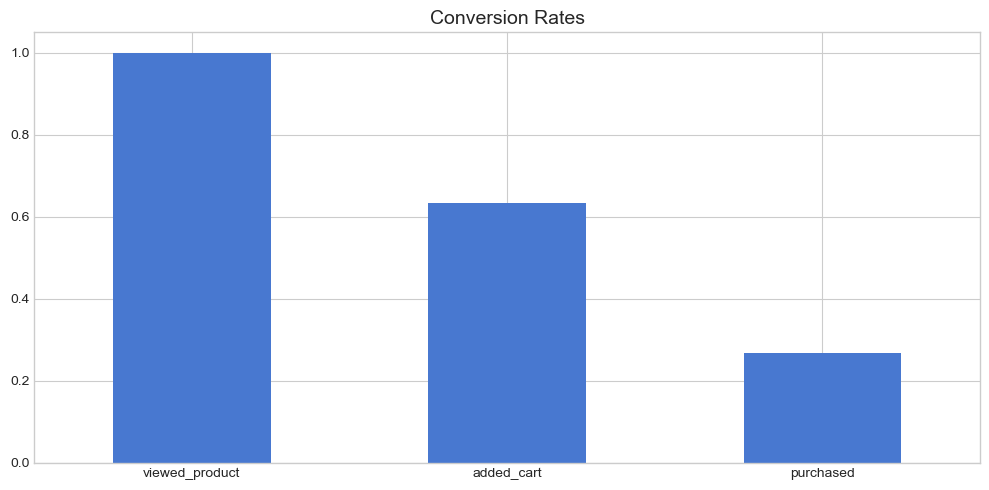

In [27]:
ordered_funnel[['viewed_product', 'added_cart', 'purchased']].mean().plot(kind='bar')
plt.title('Conversion Rates')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Purchase by Traffic Source

traffic_source
Adwords     54542
Email       81706
Facebook    18305
Organic      9124
YouTube     18082
Name: session_id, dtype: int64


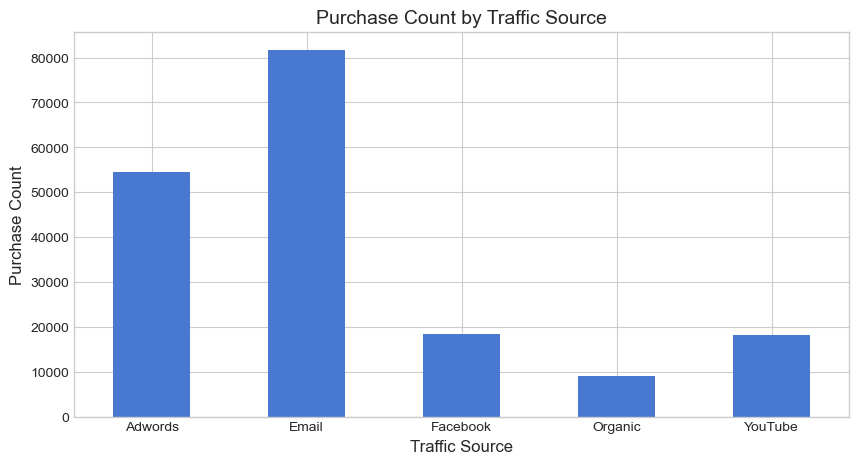

In [28]:
purchase_by_traffic_source=events[events['event_type']=='purchase'].groupby('traffic_source')['session_id'].nunique()
print(purchase_by_traffic_source)
purchase_by_traffic_source.plot(kind='bar')
plt.title('Purchase Count by Traffic Source')
plt.xlabel('Traffic Source')
plt.ylabel('Purchase Count')
plt.xticks(rotation=0)
plt.show()

Email traffic demonstrates the highest session-to-purchase conversion rate and may warrant further investigation for future marketing investment.

### Conversion Rate by Traffic Source

In [29]:
for source in (events['traffic_source']).unique():
    print(source)

Adwords
Email
Facebook
YouTube
Organic


In [30]:
source_events=events.groupby('traffic_source').size()
source_events

traffic_source
Adwords      731144
Email       1091988
Facebook     243834
Organic      122059
YouTube      242938
dtype: int64

In [31]:
ordered_funnel.head()

,session_id,viewed_product,added_cart,purchased
0,00000763-a855-4ad0-a95c-b160e749b272,1,1,0
1,0000364a-ce41-46f1-89d6-3f8704af77db,1,1,1
2,00004b15-f2d4-4687-b4c1-fc9ce336d39a,1,1,0
3,00004cf0-0d54-4347-8b0c-dccc700a2c96,1,1,0
4,00004e02-6372-47a6-aaf7-f231de654979,1,1,1


In [32]:
session_source=events.groupby('session_id')['traffic_source'].first().reset_index()

funnel_with_source=ordered_funnel.merge(session_source, on='session_id', how='left')

In [33]:
funnel_with_source

,session_id,viewed_product,added_cart,purchased,traffic_source
0,00000763-a855-4ad0-a95c-b160e749b272,1,1,0,Facebook
1,0000364a-ce41-46f1-89d6-3f8704af77db,1,1,1,Email
2,00004b15-f2d4-4687-b4c1-fc9ce336d39a,1,1,0,Email
3,00004cf0-0d54-4347-8b0c-dccc700a2c96,1,1,0,Email
4,00004e02-6372-47a6-aaf7-f231de654979,1,1,1,Adwords
...,...,...,...,...,...
681754,ffff7645-26f7-410f-8498-0c601d74c67a,1,1,0,Email
681755,ffff8086-da2c-4045-94ba-453437cd3289,1,0,0,Email
681756,ffffa9aa-4345-4c2a-b389-8fd58844472e,1,0,0,Email
681757,ffffc3b7-9bc3-44d0-935e-cfaf11c91a0e,1,1,0,Adwords


In [34]:
total_sessions=events.groupby('traffic_source')['session_id'].nunique()

source_funnel=funnel_with_source.groupby('traffic_source').agg(
    total=('session_id', 'count'),
    viewed=('viewed_product', 'sum'),
    carted=('added_cart', 'sum'),
    purchased=('purchased', 'sum')
)

source_funnel['view_rate']=source_funnel['viewed']/source_funnel['total']
source_funnel['cart_rate']=source_funnel['carted']/source_funnel['viewed']
source_funnel['purchase_rate']=source_funnel['purchased']/source_funnel['carted']
source_funnel['overall_conversion']=source_funnel['purchased']/source_funnel['total']

In [35]:
source_funnel

,total,viewed,carted,purchased,view_rate,cart_rate,purchase_rate,overall_conversion
traffic_source,,,,,,,,
Adwords,205010,205010,130001,54542,1.0,0.634120,0.419551,0.266046
Email,306313,306313,193988,81706,1.0,0.633300,0.421191,0.266740
Facebook,67933,67933,43372,18305,1.0,0.638453,0.422046,0.269457
Organic,34301,34301,21603,9124,1.0,0.629807,0.422349,0.265998
YouTube,68202,68202,43182,18082,1.0,0.633149,0.418739,0.265124


In [36]:
sources=source_funnel.index.tolist()
metrics=['view_rate', 'cart_rate', 'purchase_rate', 'overall_conversion']
labels=['View Rate', 'Cart Rate', 'Purchase Rate', 'Overall Conversion']

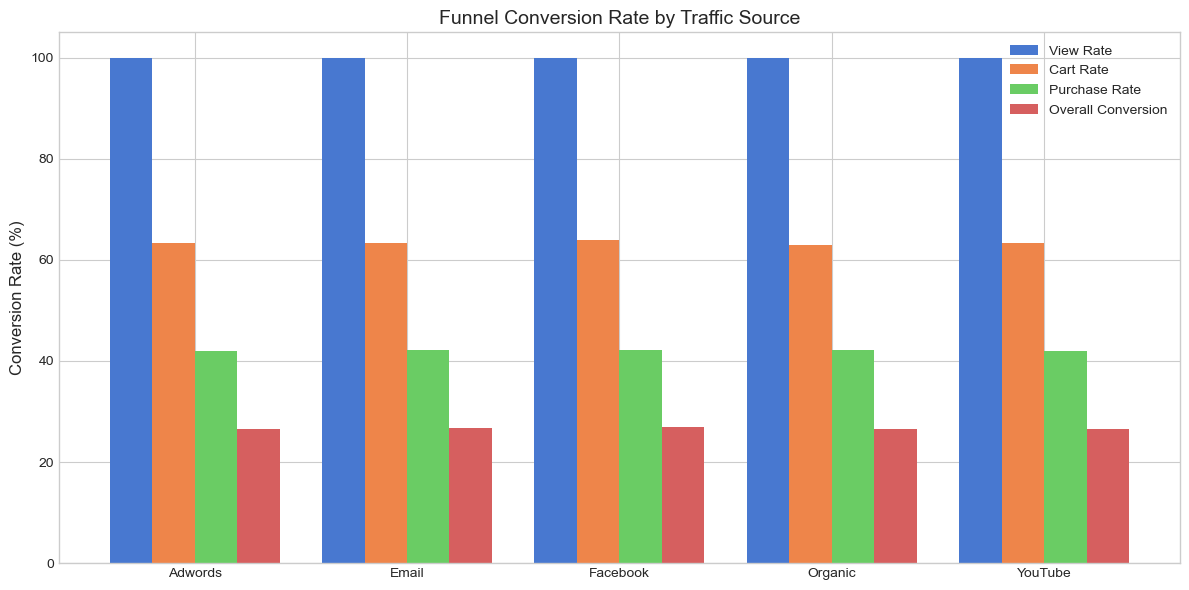

In [37]:
x=np.arange(len(sources))
width=0.2

fig, ax=plt.subplots(figsize=(12, 6))

for i, (metric, label) in enumerate(zip(metrics, labels)):
    ax.bar(x+i*width, source_funnel[metric]*100, width, label=label)

ax.set_xticks(x+width*1.5)
ax.set_xticklabels(sources)
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Funnel Conversion Rate by Traffic Source')
ax.legend()
plt.tight_layout()
plt.show()

Conversion rates are remarkably consistent across all traffic sources, with overall session-to-purchase rates ranging narrowly between 26.5% and 26.9%. Facebook shows a marginally higher cart rate (63.8%) while Organic leads slightly in cart-to-purchase conversion (42.2%).

However, given the negligible differences, conversion rate alone does not differentiate traffic sources quality. Volume and acquisition cost would be more meaningful factors - Email drives the highest purchase volume (81,706) at comparable efficiency to other sources, suggesting it is the most scalable acquisition channel in absolute terms.

In [38]:
orders=pd.read_csv('orders.csv')
print(orders.shape)
orders.head()

(125226, 9)


,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item
0,8,5,Cancelled,F,2022-10-20 10:03:00+00:00,NaN,NaN,NaN,3
1,60,44,Cancelled,F,2023-01-20 02:12:00+00:00,NaN,NaN,NaN,1
2,64,46,Cancelled,F,2021-12-06 09:11:00+00:00,NaN,NaN,NaN,1
3,89,65,Cancelled,F,2020-08-13 09:58:00+00:00,NaN,NaN,NaN,1
4,102,76,Cancelled,F,2023-01-17 08:17:00+00:00,NaN,NaN,NaN,2


In [39]:
orders.isnull().sum()

order_id             0
user_id              0
status               0
gender               0
created_at           0
returned_at     112696
shipped_at       43765
delivered_at     81342
num_of_item          0
dtype: int64

In [40]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125226 entries, 0 to 125225
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   order_id      125226 non-null  int64 
 1   user_id       125226 non-null  int64 
 2   status        125226 non-null  object
 3   gender        125226 non-null  object
 4   created_at    125226 non-null  object
 5   returned_at   12530 non-null   object
 6   shipped_at    81461 non-null   object
 7   delivered_at  43884 non-null   object
 8   num_of_item   125226 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 8.6+ MB


In [41]:
orders['created_at']=pd.to_datetime(orders['created_at'], format='mixed')
orders['shipped_at']=pd.to_datetime(orders['shipped_at'], format='mixed')
orders['delivered_at']=pd.to_datetime(orders['delivered_at'], format='mixed')
orders['returned_at']=pd.to_datetime(orders['returned_at'], format='mixed')

In [42]:
orders['days_to_deliver']=(orders['delivered_at']-orders['created_at']).dt.days
print(orders['days_to_deliver'].mean())

3.5073147388569867


On average, it took **3.5** days for the products to get delivered.

In [43]:
print(round((orders['status']=='Cancelled').mean()*100,2))

14.86


**14.86%** of the total orders got cancelled.

In [44]:
ord_items=pd.read_csv('order_items.csv')
print(ord_items.shape)
ord_items.head()

(181759, 11)


,id,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price
0,152013,104663,83582,14235,410368,Cancelled,2023-05-07 06:08:40+00:00,NaN,NaN,NaN,0.02
1,40993,28204,22551,14235,110590,Complete,2023-03-14 03:47:21+00:00,2023-03-15 22:57:00+00:00,2023-03-18 01:08:00+00:00,NaN,0.02
2,51224,35223,28215,14235,138236,Complete,2023-12-05 13:25:30+00:00,2023-12-06 01:20:00+00:00,2023-12-10 10:04:00+00:00,NaN,0.02
3,36717,25278,20165,14235,99072,Shipped,2023-12-22 20:48:19+00:00,2023-12-24 16:44:00+00:00,NaN,NaN,0.02
4,131061,90241,71954,14235,353798,Shipped,2022-06-19 16:57:59+00:00,2022-06-19 19:29:00+00:00,NaN,NaN,0.02


In [45]:
ord_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181759 entries, 0 to 181758
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 181759 non-null  int64  
 1   order_id           181759 non-null  int64  
 2   user_id            181759 non-null  int64  
 3   product_id         181759 non-null  int64  
 4   inventory_item_id  181759 non-null  int64  
 5   status             181759 non-null  object 
 6   created_at         181759 non-null  object 
 7   shipped_at         118281 non-null  object 
 8   delivered_at       63841 non-null   object 
 9   returned_at        18232 non-null   object 
 10  sale_price         181759 non-null  float64
dtypes: float64(1), int64(5), object(5)
memory usage: 15.3+ MB


In [46]:
ord_items['created_at']=pd.to_datetime(ord_items['created_at'], format='mixed')
ord_items['shipped_at']=pd.to_datetime(ord_items['shipped_at'], format='mixed')
ord_items['delivered_at']=pd.to_datetime(ord_items['delivered_at'], format='mixed')
ord_items['returned_at']=pd.to_datetime(ord_items['returned_at'], format='mixed')

In [47]:
ord_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181759 entries, 0 to 181758
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   id                 181759 non-null  int64              
 1   order_id           181759 non-null  int64              
 2   user_id            181759 non-null  int64              
 3   product_id         181759 non-null  int64              
 4   inventory_item_id  181759 non-null  int64              
 5   status             181759 non-null  object             
 6   created_at         181759 non-null  datetime64[ns, UTC]
 7   shipped_at         118281 non-null  datetime64[ns, UTC]
 8   delivered_at       63841 non-null   datetime64[ns, UTC]
 9   returned_at        18232 non-null   datetime64[ns, UTC]
 10  sale_price         181759 non-null  float64            
dtypes: datetime64[ns, UTC](4), float64(1), int64(5), object(1)
memory usage: 15.3+ MB


All fields are now of the correct datatype.

In [48]:
users=pd.read_csv('users.csv')
users.head()

,id,first_name,last_name,email,age,gender,state,street_address,postal_code,city,country,latitude,longitude,traffic_source,created_at
0,457,Timothy,Bush,timothybush@example.net,65,M,Acre,87620 Johnson Hills,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2022-07-19 13:51:00+00:00
1,6578,Elizabeth,Martinez,elizabethmartinez@example.com,34,F,Acre,1705 Nielsen Land,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2023-11-08 18:49:00+00:00
2,36280,Christopher,Mendoza,christophermendoza@example.net,13,M,Acre,125 Turner Isle Apt. 264,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Email,2019-08-24 06:10:00+00:00
3,60193,Jimmy,Conner,jimmyconner@example.com,64,M,Acre,0966 Jose Branch Apt. 008,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2020-02-15 11:26:00+00:00
4,64231,Natasha,Wilson,natashawilson@example.net,25,F,Acre,20798 Phillip Trail Apt. 392,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2020-03-13 06:45:00+00:00


In [56]:
event_user=events.merge(users, left_on='user_id', right_on='id')
event_user.head()

,id_x,user_id,sequence_number,session_id,created_at_x,ip_address,city_x,state_x,postal_code_x,browser,...,gender,state_y,street_address,postal_code_y,city_y,country,latitude,longitude,traffic_source_y,created_at_y
0,458138,35092.0,3,e24636ad-3949-4174-bd09-4e2ae7a95aa3,2022-08-01 01:10:20+00:00,92.212.103.243,Sapporo,Hokkaido,003-0030,Chrome,...,F,Hokkaido,21465 Rhonda Field Suite 992,003-0030,Sapporo,Japan,43.038536,141.447883,Display,2022-05-22 02:33:00+00:00
1,444176,34028.0,6,b334f6d8-a1fd-42e9-90e4-8e8d2af7a663,2021-07-13 23:14:04+00:00,176.14.231.160,Sapporo,Hokkaido,007-0890,Safari,...,F,Hokkaido,04357 Darren Camp Suite 558,007-0890,Sapporo,Japan,43.136565,141.437433,Email,2020-02-20 01:20:00+00:00
2,170896,13199.0,4,1df890d5-6783-4602-aa0a-e6668fed606e,2023-11-05 10:45:45+00:00,114.185.130.47,São Paulo,São Paulo,02220-000,Safari,...,F,São Paulo,876 Stewart Port Apt. 445,02220-000,São Paulo,Brasil,-23.484761,-46.574390,Search,2021-08-27 13:52:00+00:00
3,1147243,87818.0,3,e99fd570-3c66-4475-ab68-41c4a0da4bbc,2021-01-01 06:55:11+00:00,138.36.176.82,São Paulo,São Paulo,02675-031,Chrome,...,F,São Paulo,981 Brandi Via,02675-031,São Paulo,Brasil,-23.472562,-46.746566,Facebook,2020-05-26 07:42:00+00:00
4,604658,46234.0,3,d566d275-4aea-4e90-be87-f119b4369f48,2023-12-22 12:38:20+00:00,163.100.101.188,São Paulo,São Paulo,02675-031,Safari,...,F,São Paulo,5135 Anderson Flat Suite 364,02675-031,São Paulo,Brasil,-23.472562,-46.746566,Search,2023-05-22 15:22:00+00:00


In [55]:
event_user.columns.tolist()

['id_x',
 'user_id',
 'sequence_number',
 'session_id',
 'created_at_x',
 'ip_address',
 'city_x',
 'state_x',
 'postal_code_x',
 'browser',
 'traffic_source_x',
 'uri',
 'event_type',
 'id_y',
 'first_name',
 'last_name',
 'email',
 'age',
 'gender',
 'state_y',
 'street_address',
 'postal_code_y',
 'city_y',
 'country',
 'latitude',
 'longitude',
 'traffic_source_y',
 'created_at_y']

gender
Female    91009
Male      90750
Name: id_x, dtype: int64


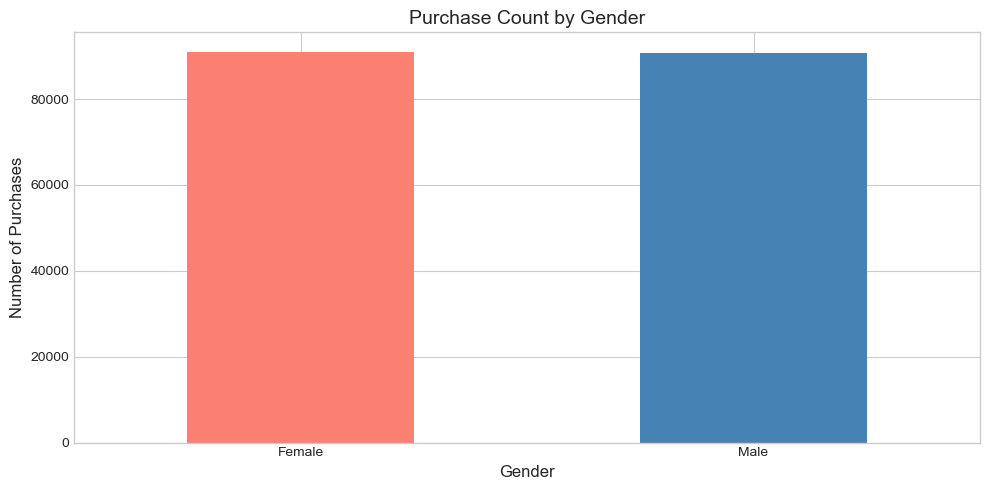

In [61]:
gender_purchases=event_user[event_user['event_type']=='purchase'].groupby('gender')['id_x'].count()
gender_purchases.index=gender_purchases.index.map({'F':'Female', 'M':'Male'})

print(gender_purchases)

gender_purchases.plot(kind='bar', color=['salmon', 'steelblue'])
plt.title('Purchase Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Females have made more purchases but the difference is negligible.**

In [62]:
products=pd.read_csv('products.csv')
products.head()

,id,cost,category,name,brand,retail_price,department,sku,distribution_center_id
0,13842,2.51875,Accessories,Low Profile Dyed Cotton Twill Cap - Navy W39S55D,MG,6.25,Women,EBD58B8A3F1D72F4206201DA62FB1204,1
1,13928,2.33835,Accessories,Low Profile Dyed Cotton Twill Cap - Putty W39S55D,MG,5.95,Women,2EAC42424D12436BDD6A5B8A88480CC3,1
2,14115,4.87956,Accessories,Enzyme Regular Solid Army Caps-Black W35S45D,MG,10.99,Women,EE364229B2791D1EF9355708EFF0BA34,1
3,14157,4.64877,Accessories,Enzyme Regular Solid Army Caps-Olive W35S45D (...,MG,10.99,Women,00BD13095D06C20B11A2993CA419D16B,1
4,14273,6.50793,Accessories,Washed Canvas Ivy Cap - Black W11S64C,MG,15.99,Women,F531DC20FDE20B7ADF3A73F52B71D0AF,1


### Revenue Analysis

In [63]:
product_ord_items=products.merge(ord_items, left_on='id', right_on='product_id')
product_ord_items.head()

,id_x,cost,category,name,brand,retail_price,department,sku,distribution_center_id,id_y,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price
0,13842,2.51875,Accessories,Low Profile Dyed Cotton Twill Cap - Navy W39S55D,MG,6.25,Women,EBD58B8A3F1D72F4206201DA62FB1204,1,96073,66090,52790,13842,259294,Complete,2022-04-20 07:45:00+00:00,2022-04-22 17:18:00+00:00,2022-04-26 21:03:00+00:00,NaT,6.25
1,13842,2.51875,Accessories,Low Profile Dyed Cotton Twill Cap - Navy W39S55D,MG,6.25,Women,EBD58B8A3F1D72F4206201DA62FB1204,1,167662,115482,92244,13842,452664,Complete,2023-10-07 16:21:27+00:00,2023-10-08 04:29:00+00:00,2023-10-11 07:53:00+00:00,NaT,6.25
2,13842,2.51875,Accessories,Low Profile Dyed Cotton Twill Cap - Navy W39S55D,MG,6.25,Women,EBD58B8A3F1D72F4206201DA62FB1204,1,143537,98819,78850,13842,387492,Shipped,2022-04-06 14:08:57+00:00,2022-04-03 22:14:00+00:00,NaT,NaT,6.25
3,13842,2.51875,Accessories,Low Profile Dyed Cotton Twill Cap - Navy W39S55D,MG,6.25,Women,EBD58B8A3F1D72F4206201DA62FB1204,1,179246,123454,98574,13842,483925,Shipped,2022-07-18 16:09:14+00:00,2022-07-21 13:55:00+00:00,NaT,NaT,6.25
4,13928,2.33835,Accessories,Low Profile Dyed Cotton Twill Cap - Putty W39S55D,MG,5.95,Women,2EAC42424D12436BDD6A5B8A88480CC3,1,15364,10640,8508,13928,41491,Cancelled,2021-10-02 09:32:03+00:00,NaT,NaT,NaT,5.95


In [64]:
product_ord_items=product_ord_items.rename(columns={'id_x':'product_master_id', 'id_y':'order_item_id'})

In [65]:
top_categories=product_ord_items.groupby('category')['sale_price'].sum().sort_values(ascending=False)
top_categories.head(10)

category
Outerwear & Coats                1.301571e+06
Jeans                            1.253644e+06
Sweaters                         8.426515e+05
Suits & Sport Coats              6.667673e+05
Fashion Hoodies & Sweatshirts    6.493528e+05
Swim                             6.467387e+05
Sleep & Lounge                   5.373921e+05
Shorts                           5.120695e+05
Tops & Tees                      4.915514e+05
Dresses                          4.644168e+05
Name: sale_price, dtype: float64

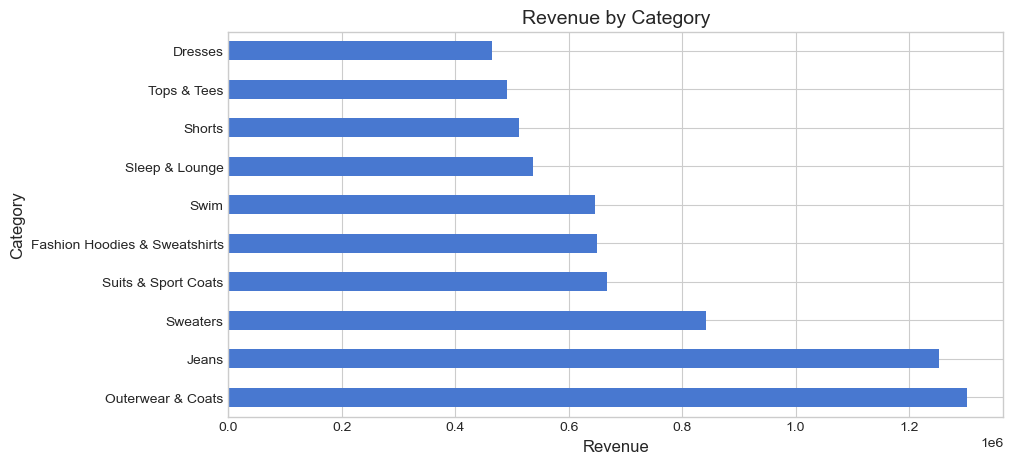

In [66]:
top_categories.head(10).plot(kind='barh')
plt.title('Revenue by Category')
plt.xlabel('Revenue')
plt.ylabel('Category')
plt.show()

In [67]:
return_rate_by_category=product_ord_items.groupby('category').agg(
            total_items=('order_item_id', 'count'),
            returned_items=('returned_at', lambda x: x.notna().sum()
            ))

return_rate_by_category['return_rate']=round(return_rate_by_category['returned_items']/return_rate_by_category['total_items']*100, 2)

return_rate_by_category_sorted=return_rate_by_category.sort_values('return_rate', ascending=False)

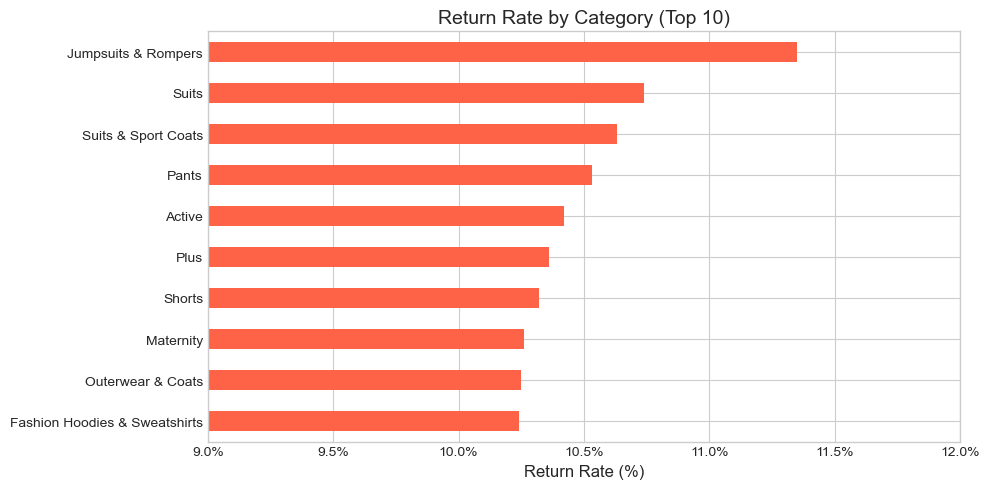

In [71]:
top_return_categories=return_rate_by_category_sorted.head(10)
top_return_categories['return_rate'].plot(kind='barh', color='tomato')
plt.title('Return Rate by Category (Top 10)')
plt.xlabel('Return Rate (%)')
plt.ylabel('')
plt.xlim(9, 12)
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x}%'))
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Jumpsuits & Rompers, Suits, and Suits & Sport Coats have the highest return rates (~10.6–11.4%),
suggesting fit and sizing issues are most common in structured or occasion-wear categories.
Active, Plus, and Shorts cluster closely around 10.4%, indicating a consistently moderate
return rate across casual wear. Overall, the variation across top categories is narrow (~1%),
which may reflect the simulated nature of the dataset.

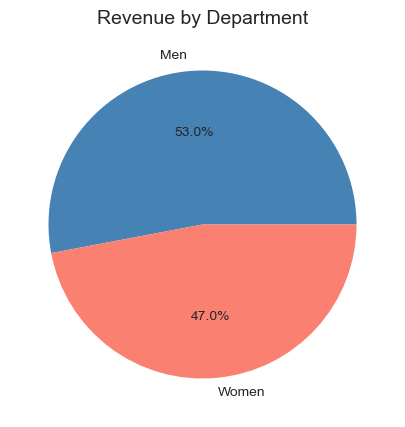

In [93]:
dept_revenue = product_ord_items.groupby('department')['sale_price'].sum()

dept_revenue.plot(kind='pie', autopct='%1.1f%%', colors=['steelblue', 'salmon'])
plt.ylabel('')
plt.title('Revenue by Department')
plt.show()

Although women have made more purchases, men's department has brought in more revenue. Prioritising marketing for men's department products could be a higher-revenue opportunity.

C:\Users\DELL\AppData\Local\Temp\ipykernel_19816\1552081449.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  ord_items['order_month']=ord_items['created_at'].dt.to_period('M')


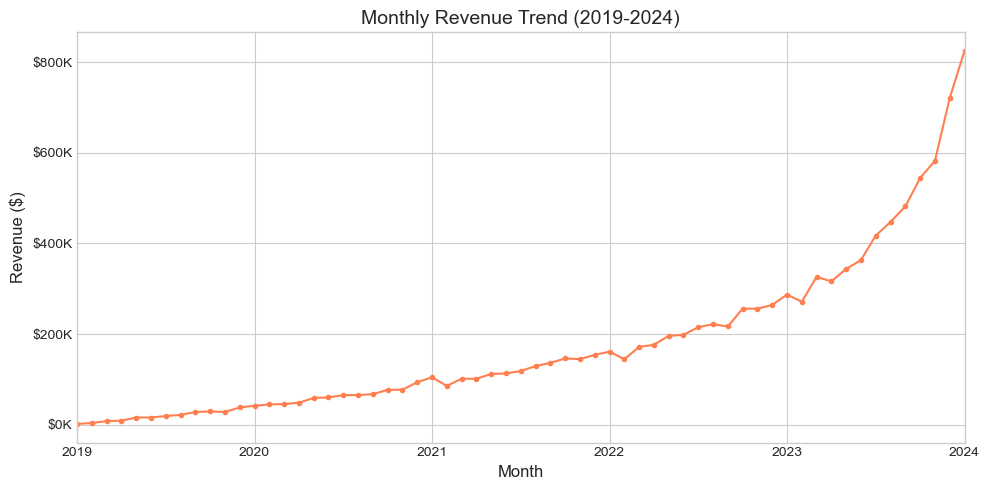

In [85]:
ord_items['order_month']=ord_items['created_at'].dt.to_period('M')
monthly_revenue=ord_items.groupby('order_month')['sale_price'].sum()
monthly_revenue.index=monthly_revenue.index.to_timestamp()

monthly_revenue.plot(kind='line', marker='o', markersize=3, linewidth=1.5, color='coral')
plt.title('Monthly Revenue Trend (2019-2024)')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

Revenue shows consistent month-over-month growth from 2019, with a sharp acceleration
from mid-2023 onward — peaking near $820K in early 2024. The steep upward curve in the
final year likely reflects the compounding effect of a growing user base in this simulated
dataset rather than a true seasonal or campaign-driven spike.

### Brand Analysis

brand
Calvin Klein         208658.220517
Diesel               199889.419819
7 For All Mankind    188302.980560
Carhartt             183997.288993
True Religion        180472.449564
Tommy Hilfiger       126127.230120
Volcom               106950.029760
Quiksilver           105024.680113
Columbia             103145.679712
The North Face       101393.870102
Name: sale_price, dtype: float64


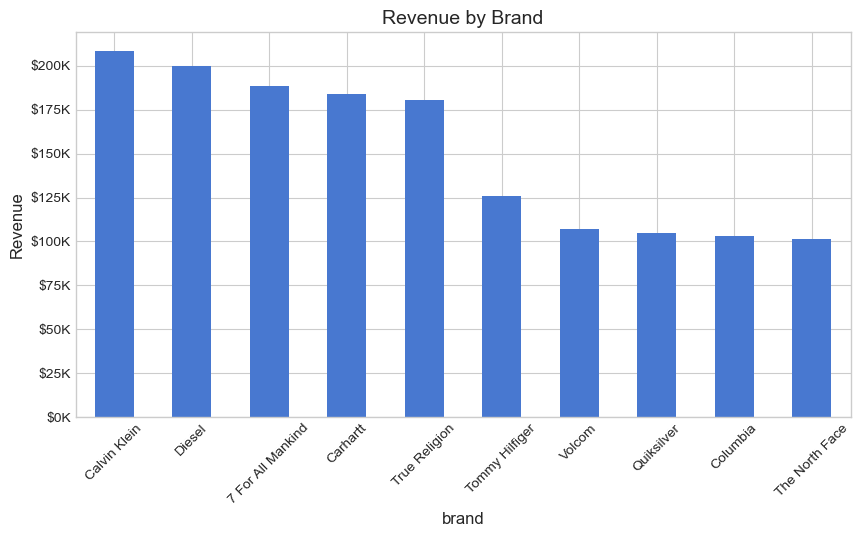

In [88]:
top_brands=product_ord_items.groupby('brand')['sale_price'].sum().sort_values(ascending=False)
print(top_brands.head(10))
top_brands.head(10).plot(kind='bar')
plt.ylabel('Revenue')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.title('Revenue by Brand')
plt.xticks(rotation=45)
plt.show()

In [73]:
product_ord_items['brand'].value_counts().head(10)

brand
Allegra K         6292
Calvin Klein      3280
Carhartt          2601
Volcom            1871
Hanes             1858
Nautica           1789
Quiksilver        1779
Tommy Hilfiger    1671
Levi's            1535
Diesel            1523
Name: count, dtype: int64

### Cohort Analysis

In [75]:
# Getting each user's first month purchase
orders['order_month']=orders['created_at'].dt.to_period('M')
                       
first_purchase=(orders.groupby('user_id')['order_month'].min().reset_index())
first_purchase.columns=['user_id', 'cohort_month']

C:\Users\DELL\AppData\Local\Temp\ipykernel_19816\1357462253.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  orders['order_month']=orders['created_at'].dt.to_period('M')


In [76]:
# Merging cohort month back onto orders
orders_cohort=orders.merge(first_purchase, on='user_id')

In [77]:
# Calculating months since first purchase
orders_cohort['months_since_first']=(orders_cohort['order_month']-orders_cohort['cohort_month']).apply(lambda x:x.n)

In [78]:
# Counting distinct users per cohort period
cohort_data=orders_cohort.groupby(['cohort_month', 'months_since_first'])['user_id'].nunique().reset_index()

cohort_pivot=cohort_data.pivot(index='cohort_month', columns='months_since_first', values='user_id')

In [79]:
# Converting to retention rate
cohort_retention=cohort_pivot.divide(cohort_pivot[0], axis=0)*100

In [80]:
cohort_retention_filtered=cohort_retention[cohort_retention.index>=pd.Period('2022-01', 'M')]
cohort_retention_filtered=cohort_retention_filtered.iloc[:, :13]

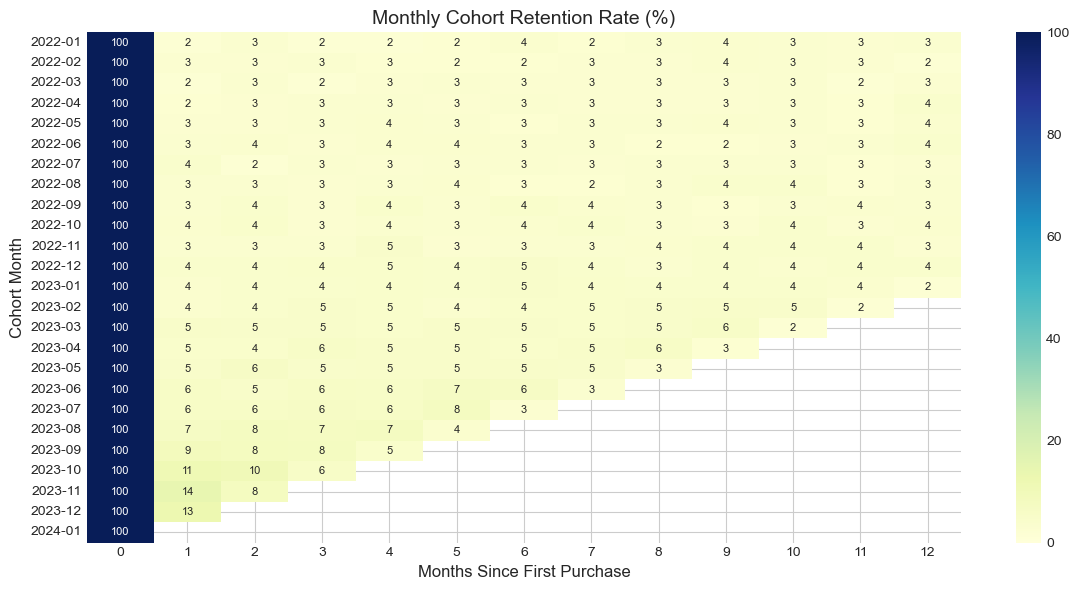

In [91]:
plt.figure(figsize=(12,6))
sns.heatmap(cohort_retention_filtered, annot=True, fmt='.0f', cmap='YlGnBu', vmin=0, vmax=100, annot_kws={"size": 8})

plt.title('Monthly Cohort Retention Rate (%)')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()

In [ ]:
# Exclude column 0 (that's always 100%) and young cohorts
stable_cohorts = cohort_retention[
    cohort_retention.index < pd.Period('2023-09', 'M')
]

# Drop column 0
retention_only = stable_cohorts.iloc[:, 1:]

print("Mean retention by month:")
print(retention_only.mean().round(1))

print("\nOverall mean retention (months 1-12):")
print(retention_only.stack().mean().round(1))

print("\nMin:", round(retention_only.stack().min(),2))
print("Max:", round(retention_only.stack().max(),2))

Mean retention by month:
months_since_first
1     2.8
2     2.8
3     2.9
4     2.9
5     2.9
6     2.9
7     2.7
8     2.7
9     2.6
10    2.6
11    2.4
12    2.5
13    2.4
14    2.4
15    2.4
16    2.4
17    2.4
18    2.2
19    2.2
20    2.3
21    2.4
22    2.1
23    2.1
24    2.3
25    2.2
26    2.0
27    2.1
28    2.3
29    2.1
30    1.9
31    2.0
32    1.8
33    2.1
34    2.3
35    1.9
36    2.5
37    2.1
38    2.1
39    2.1
40    2.0
41    2.1
42    2.1
43    1.7
44    2.5
45    1.8
46    1.9
47    1.8
48    1.7
49    2.1
50    1.8
51    1.8
52    1.8
53    1.5
54    3.5
55    1.0
56    2.4
57    1.9
58    1.2
dtype: float64


Overall mean retention (months 1-12):
2.4

Min: 0.21
Max: 13.64


In [248]:
# What % of users made more than 1 purchase?
repeat_buyers = orders.groupby('user_id')['order_id'].nunique()
print((repeat_buyers > 1).mean() * 100)  # % of users who are repeat buyers

37.7442406676328


In [249]:
# Average number of purchases per repeat buyer
repeat_buyers = orders.groupby('user_id')['order_id'].nunique()
print(repeat_buyers[repeat_buyers > 1].mean().round(2))

# Distribution
print(repeat_buyers.value_counts().sort_index().head(10))

2.5
order_id
1    49832
2    20231
3     4992
4     4989
Name: count, dtype: int64


62.3% of customers made only one purchase, while 37.7% returned at least once. Among repeat buyers, the average order count was 2.5. The steepest drop-off occurs between the second and third purchase — 20,231 customers bought twice but only ~5,000 progressed to a third purchase. Combined with a flat monthly retention rate of ~2.8%, this suggests repeat purchases happen infrequently over long intervals rather than regularly. Re-engagement campaigns targeted at customers 3–6 months after their second purchase represent the highest-leverage retention opportunity.

# Key Findings

### Funnel
- 63.39% of product viewers added an item to cart
- 42.06% of cart sessions completed a purchase
- Overall product-view to purchase rate: 26.7%

### Traffic Source
- Email drove the highest purchase volume
- Conversion rates are consistent across all traffic sources

### Revenue
- Men's department generated higher total revenue ($5.74M) than Women's ($5.09M) despite women making slightly more purchases, suggesting higher average order value in men's products
- Cancellation rate stood at 14.86%
- Revenue grew consistently from 2019 to 2024, accelerating sharply in late 2023 — peaking near $820K/month by early 2024.
- Jumpsuits & Rompers (11.4%) and Suits (10.7%) have the highest return rates, suggesting fit and sizing friction in structured/occasion wear categories.

### Retention
- 37.7% of customers made more than one purchase
- Average repeat buyers placed 2.5 orders
- Steepest drop-off occurs between 2nd and 3rd purchase (20,231 vs ~5,000 customers)
- Mean monthly cohort retention rate averaged 12.8%, indicating purchases are infrequent but a meaningful repeat-buyer segment exists

# Limitations

- **Session-based funnel:** The funnel is constructed at session level, not user level. A single user abandoning and returning across multiple sessions is counted as separate funnel entries.

- **Traffic source attribution:** Attribution uses the source recorded at the time of the event. Multi-touch attribution (where a user arrives via multiple sources before purchasing) is not accounted for.

- **Cohort retention scope:** Cohort analysis measures repeat purchasing 
  behavior only. Browsing activity, wishlist additions, or other engagement 
  signals between purchases are not captured.

- **Causal inference:** Associations identified in this analysis (e.g. between traffic source and conversion, or department and revenue) are correlational. No causal claims are made without further experimental validation such as A/B testing.